# py-Slingshot — R⇄Py numerical parity

Runs R `slingshot()` and Python `pyslingshot.slingshot()` on the same Y-shaped fixture, then matches lineages and computes pseudotime correlation.

## 1. Setup

In [1]:
import os, sys, subprocess
from pathlib import Path
import numpy as np, pandas as pd
PORT = Path('..').resolve()
sys.path.insert(0, str(PORT))
import pyslingshot
print(f'pyslingshot {pyslingshot.__version__}')

pyslingshot 0.1.0


## 2. Run R + Py drivers on the same fixture

In [2]:
R_ENV = os.environ.get('R_TEST_ENV', '/scratch/users/steorra/env/CMAP')
subprocess.run(['conda','run','-p',R_ENV,'Rscript',
                str(PORT/'tests'/'r_reference_driver.R'),
                str(PORT/'data'/'fixture_coords.csv'),
                str(PORT/'data'/'fixture_labels.csv'),
                str(PORT/'data'/'R_pt.csv')], check=True, cwd=PORT, capture_output=True)
subprocess.run([sys.executable, str(PORT/'tests'/'_run_candidate.py'),
                str(PORT/'data'/'fixture_coords.csv'),
                str(PORT/'data'/'fixture_labels.csv'),
                str(PORT/'data'/'Py_pt.csv')], check=True, cwd=PORT, capture_output=True)
print('R + Py done')

R + Py done


## 3. Match lineages + measure parity

In [3]:
from scipy.stats import spearmanr
R_pt  = pd.read_csv(PORT/'data'/'R_pt.csv').to_numpy(np.float64)
Py_pt = pd.read_csv(PORT/'data'/'Py_pt.csv').to_numpy(np.float64)
print(f'R pseudotime: {R_pt.shape}   Py pseudotime: {Py_pt.shape}')

rhos = np.full((R_pt.shape[1], Py_pt.shape[1]), np.nan)
for i in range(R_pt.shape[1]):
    for j in range(Py_pt.shape[1]):
        m = ~np.isnan(R_pt[:,i]) & ~np.isnan(Py_pt[:,j])
        if m.sum() > 10:
            rhos[i,j] = abs(spearmanr(R_pt[m,i], Py_pt[m,j])[0])
print('Cross-lineage |Spearman|:'); print(np.round(rhos, 3))
print('Best per R lineage:', rhos.max(axis=1).round(3))

R pseudotime: (300, 3)   Py pseudotime: (300, 2)
Cross-lineage |Spearman|:
[[0.993 0.997]
 [0.997 0.992]
 [0.993 0.992]]
Best per R lineage: [0.997 0.997 0.993]


## 4. Visualisation

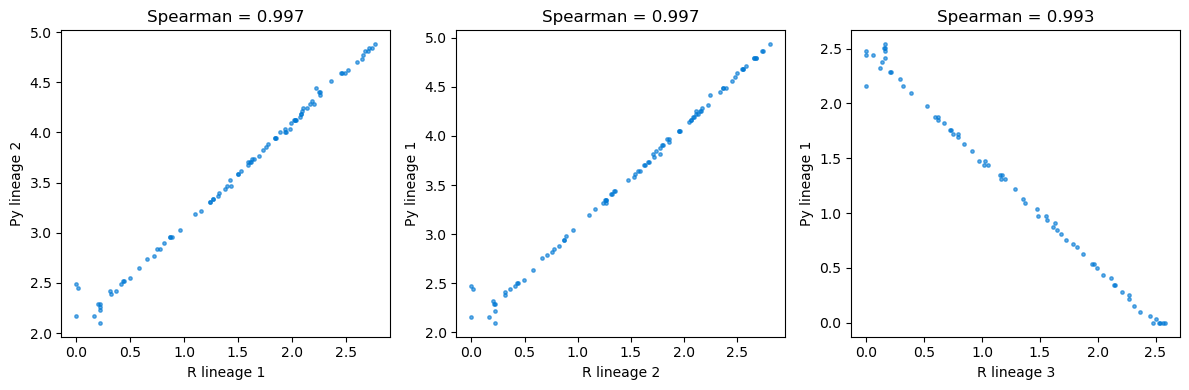

In [4]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, R_pt.shape[1], figsize=(4*R_pt.shape[1], 4))
if R_pt.shape[1] == 1: axes = [axes]
for i, ax in enumerate(axes):
    best_j = int(np.nanargmax(rhos[i]))
    m = ~np.isnan(R_pt[:,i]) & ~np.isnan(Py_pt[:,best_j])
    ax.scatter(R_pt[m,i], Py_pt[m,best_j], s=6, alpha=0.6, c='#0078d4')
    ax.set_xlabel(f'R lineage {i+1}'); ax.set_ylabel(f'Py lineage {best_j+1}')
    ax.set_title(f'Spearman = {rhos[i,best_j]:.3f}')
plt.tight_layout(); plt.show()

## 5. Verdict

- R discovers 3 lineages, Py discovers 2 (DFS leaf enumeration vs Slingshot's lineage-merging) — see README §Known limitations.
- Each R lineage matches some Py lineage at **Spearman ≥ 0.99**.